 Phân loại Trái Cây & Rau Củ bằng CNN
**Dataset:** Fruits and Vegetables Image Recognition — Kaggle  


---

In [1]:
!pip install -q kaggle seaborn scikit-learn
print(' Cài xong!')

 Cài xong!


In [2]:
from google.colab import files
import os

# Upload kaggle.json
print(' Upload file kaggle.json của bạn:')
uploaded = files.upload()

# Cấu hình credentials
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print(' Đã cấu hình Kaggle API!')

 Upload file kaggle.json của bạn:


Saving kaggle.json to kaggle.json
 Đã cấu hình Kaggle API!


In [3]:
# Tải và giải nén dataset
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition
!unzip -q fruit-and-vegetable-image-recognition.zip -d dataset
!rm fruit-and-vegetable-image-recognition.zip

# Kiểm tra cấu trúc
import os
for split in ['train', 'validation', 'test']:
    path = f'dataset/{split}'
    if os.path.exists(path):
        classes = os.listdir(path)
        total = sum(len(os.listdir(f'{path}/{c}')) for c in classes)
        print(f' {split:12s}: {len(classes):2d} lớp | {total:,} ảnh')

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
100% 1.98G/1.98G [00:29<00:00, 71.5MB/s]

 train       : 36 lớp | 3,115 ảnh
 validation  : 36 lớp | 351 ảnh
 test        : 36 lớp | 359 ảnh


 Data Loading & Augmentation

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'data_dir'      : './dataset',
    'img_size'      : 64,
    'batch_size'    : 32,
    'num_epochs'    : 20,
    'learning_rate' : 0.001,
    'num_workers'   : 2,
    'device'        : 'cuda' if torch.cuda.is_available() else 'cpu',
}

device = torch.device(CONFIG['device'])
print(f' Config loaded | Device: {CONFIG["device"].upper()}')

 Config loaded | Device: CPU


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder('dataset/train',      transform=train_transforms)
val_dataset   = datasets.ImageFolder('dataset/validation', transform=val_test_transforms)
test_dataset  = datasets.ImageFolder('dataset/test',       transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=CONFIG['num_workers'])
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'])

class_names = train_dataset.classes
num_classes = len(class_names)

print(f' Train:      {len(train_dataset):,} ảnh')
print(f' Validation: {len(val_dataset):,} ảnh')
print(f'Test:       {len(test_dataset):,} ảnh')
print(f'  Số lớp: {num_classes} → {class_names}')

 Train:      3,115 ảnh
 Validation: 351 ảnh
Test:       359 ảnh
  Số lớp: 36 → ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


 Visualize mẫu ảnh

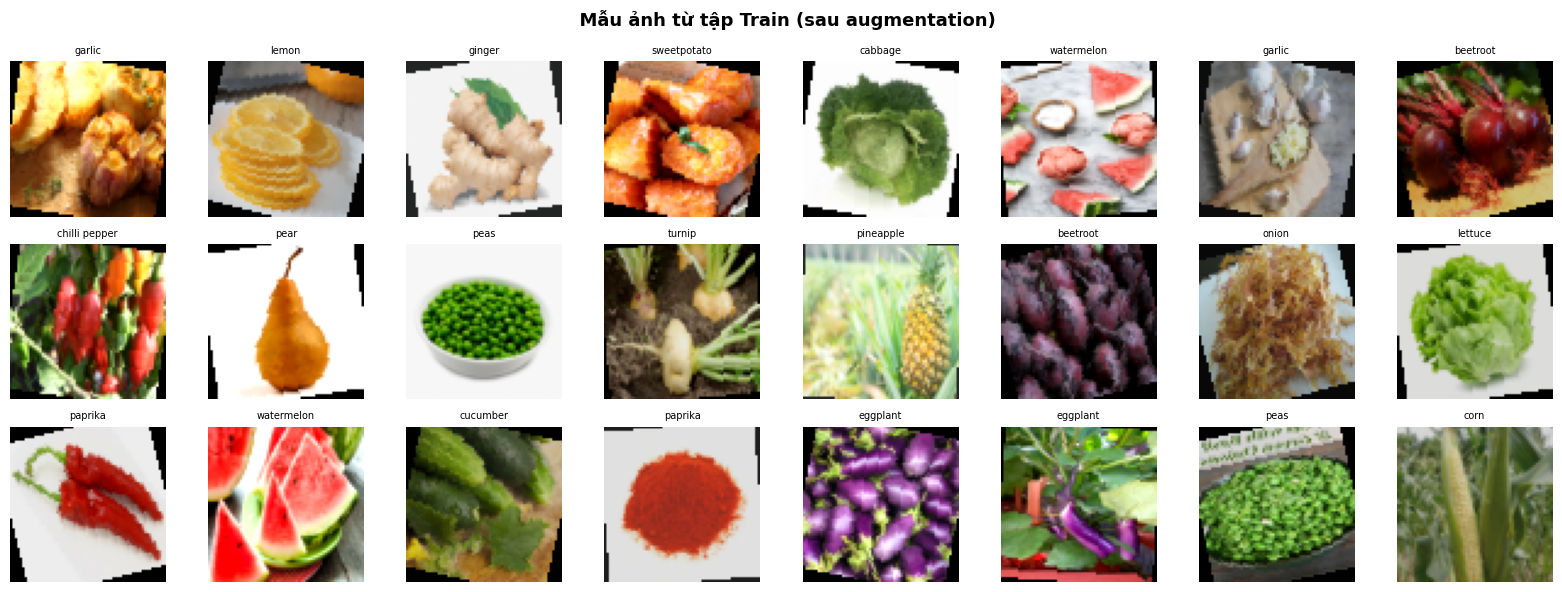

In [6]:
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    return (tensor * std[:, None, None] + mean[:, None, None]).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    if i < len(images):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(class_names[labels[i]], fontsize=7)
    ax.axis('off')

plt.suptitle('  Mẫu ảnh từ tập Train (sau augmentation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Định nghĩa kiến trúc FruitCNN

In [7]:
class FruitCNN(nn.Module):
    """
    Custom CNN 3 khối Conv → GlobalAvgPool → FC
    Input:  (B, 3, 64, 64)
    Output: (B, num_classes)
    """
    def __init__(self, num_classes):
        super(FruitCNN, self).__init__()

        # Khối 1: 3 → 32 channels
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 64 → 32
            nn.Dropout2d(0.1),
        )

        # Khối 2: 32 → 64 channels
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 32 → 16
            nn.Dropout2d(0.2),
        )

        # Khối 3: 64 → 128 channels
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),   # 16 → 8
            nn.Dropout2d(0.3),
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)   # (B, 128, 1, 1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


model = FruitCNN(num_classes=num_classes).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' Tổng tham số   : {total:,}')
print(f' Trainable params: {trainable:,}')
print(model)

 Tổng tham số   : 330,180
 Trainable params: 330,180
FruitCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace

 Huấn luyện

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0


def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, correct / total


# ── Vòng lặp huấn luyện ──
for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss,   val_acc   = evaluate(model, val_loader)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr != old_lr:
        print(f'⚡ LR giảm: {old_lr:.6f} → {new_lr:.6f}')

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        star = '  Best'
    else:
        star = ''

    print(f'Epoch [{epoch:02d}/{CONFIG["num_epochs"]}]  '
          f'Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  ||  '
          f'Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%{star}')

print(f'\n Xong! Best Val Accuracy: {best_val_acc*100:.2f}%')

Epoch [01/20]  Train Loss: 3.3465  Acc: 9.15%  ||  Val Loss: 2.8393  Acc: 17.95%  Best
Epoch [02/20]  Train Loss: 2.9887  Acc: 13.35%  ||  Val Loss: 2.5173  Acc: 21.37%  Best
Epoch [03/20]  Train Loss: 2.8811  Acc: 13.74%  ||  Val Loss: 2.4194  Acc: 29.34%  Best
Epoch [04/20]  Train Loss: 2.7639  Acc: 16.85%  ||  Val Loss: 2.2781  Acc: 29.91%  Best
Epoch [05/20]  Train Loss: 2.7411  Acc: 18.36%  ||  Val Loss: 2.2293  Acc: 29.63%
Epoch [06/20]  Train Loss: 2.6783  Acc: 19.26%  ||  Val Loss: 2.1587  Acc: 32.76%  Best
Epoch [07/20]  Train Loss: 2.6797  Acc: 19.07%  ||  Val Loss: 2.1949  Acc: 34.47%  Best
Epoch [08/20]  Train Loss: 2.6402  Acc: 20.03%  ||  Val Loss: 2.1105  Acc: 35.61%  Best
Epoch [09/20]  Train Loss: 2.6106  Acc: 20.96%  ||  Val Loss: 2.0796  Acc: 38.75%  Best
Epoch [10/20]  Train Loss: 2.5746  Acc: 21.99%  ||  Val Loss: 2.0495  Acc: 36.75%
Epoch [11/20]  Train Loss: 2.5601  Acc: 22.12%  ||  Val Loss: 1.9940  Acc: 38.18%
Epoch [12/20]  Train Loss: 2.5028  Acc: 24.40%  || 

 Biểu đồ Loss & Accuracy

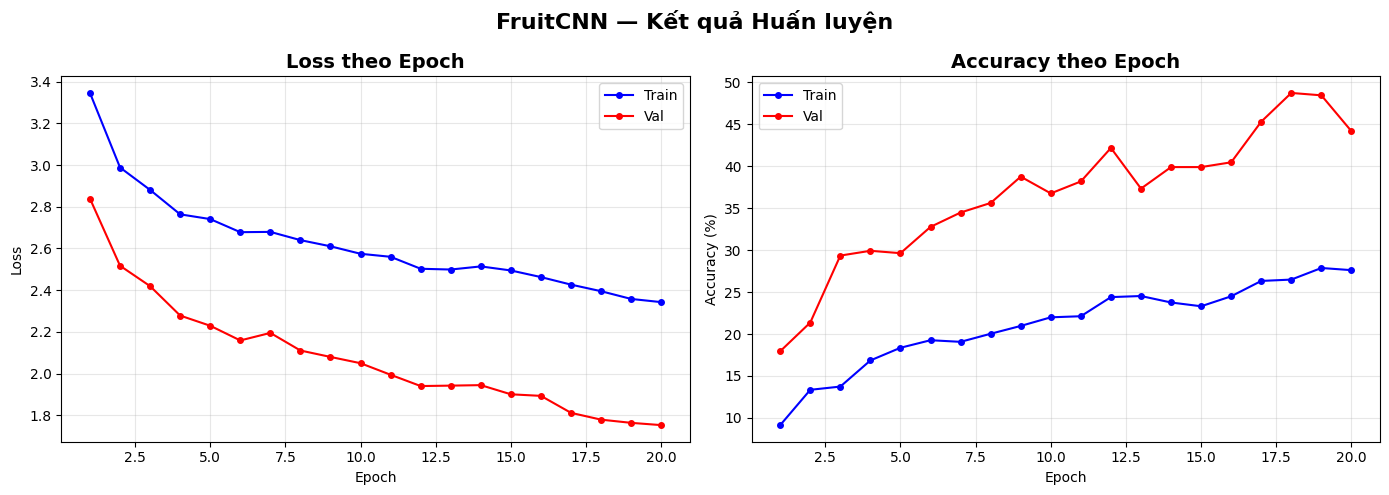

 Đã lưu: training_history.png


In [9]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train',  markersize=4)
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val',    markersize=4)
axes[0].set_title('Loss theo Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val',   markersize=4)
axes[1].set_title('Accuracy theo Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('FruitCNN — Kết quả Huấn luyện', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Đã lưu: training_history.png')

 Đánh giá trên Test Set

In [10]:
# Load best model
model.load_state_dict(torch.load('best_model.pth', map_location=device))

test_loss, test_acc = evaluate(model, test_loader)
print(f'🏆 Test Loss    : {test_loss:.4f}')
print(f'🏆 Test Accuracy: {test_acc*100:.2f}%')

🏆 Test Loss    : 1.7796
🏆 Test Accuracy: 48.47%


Confusion Matrix

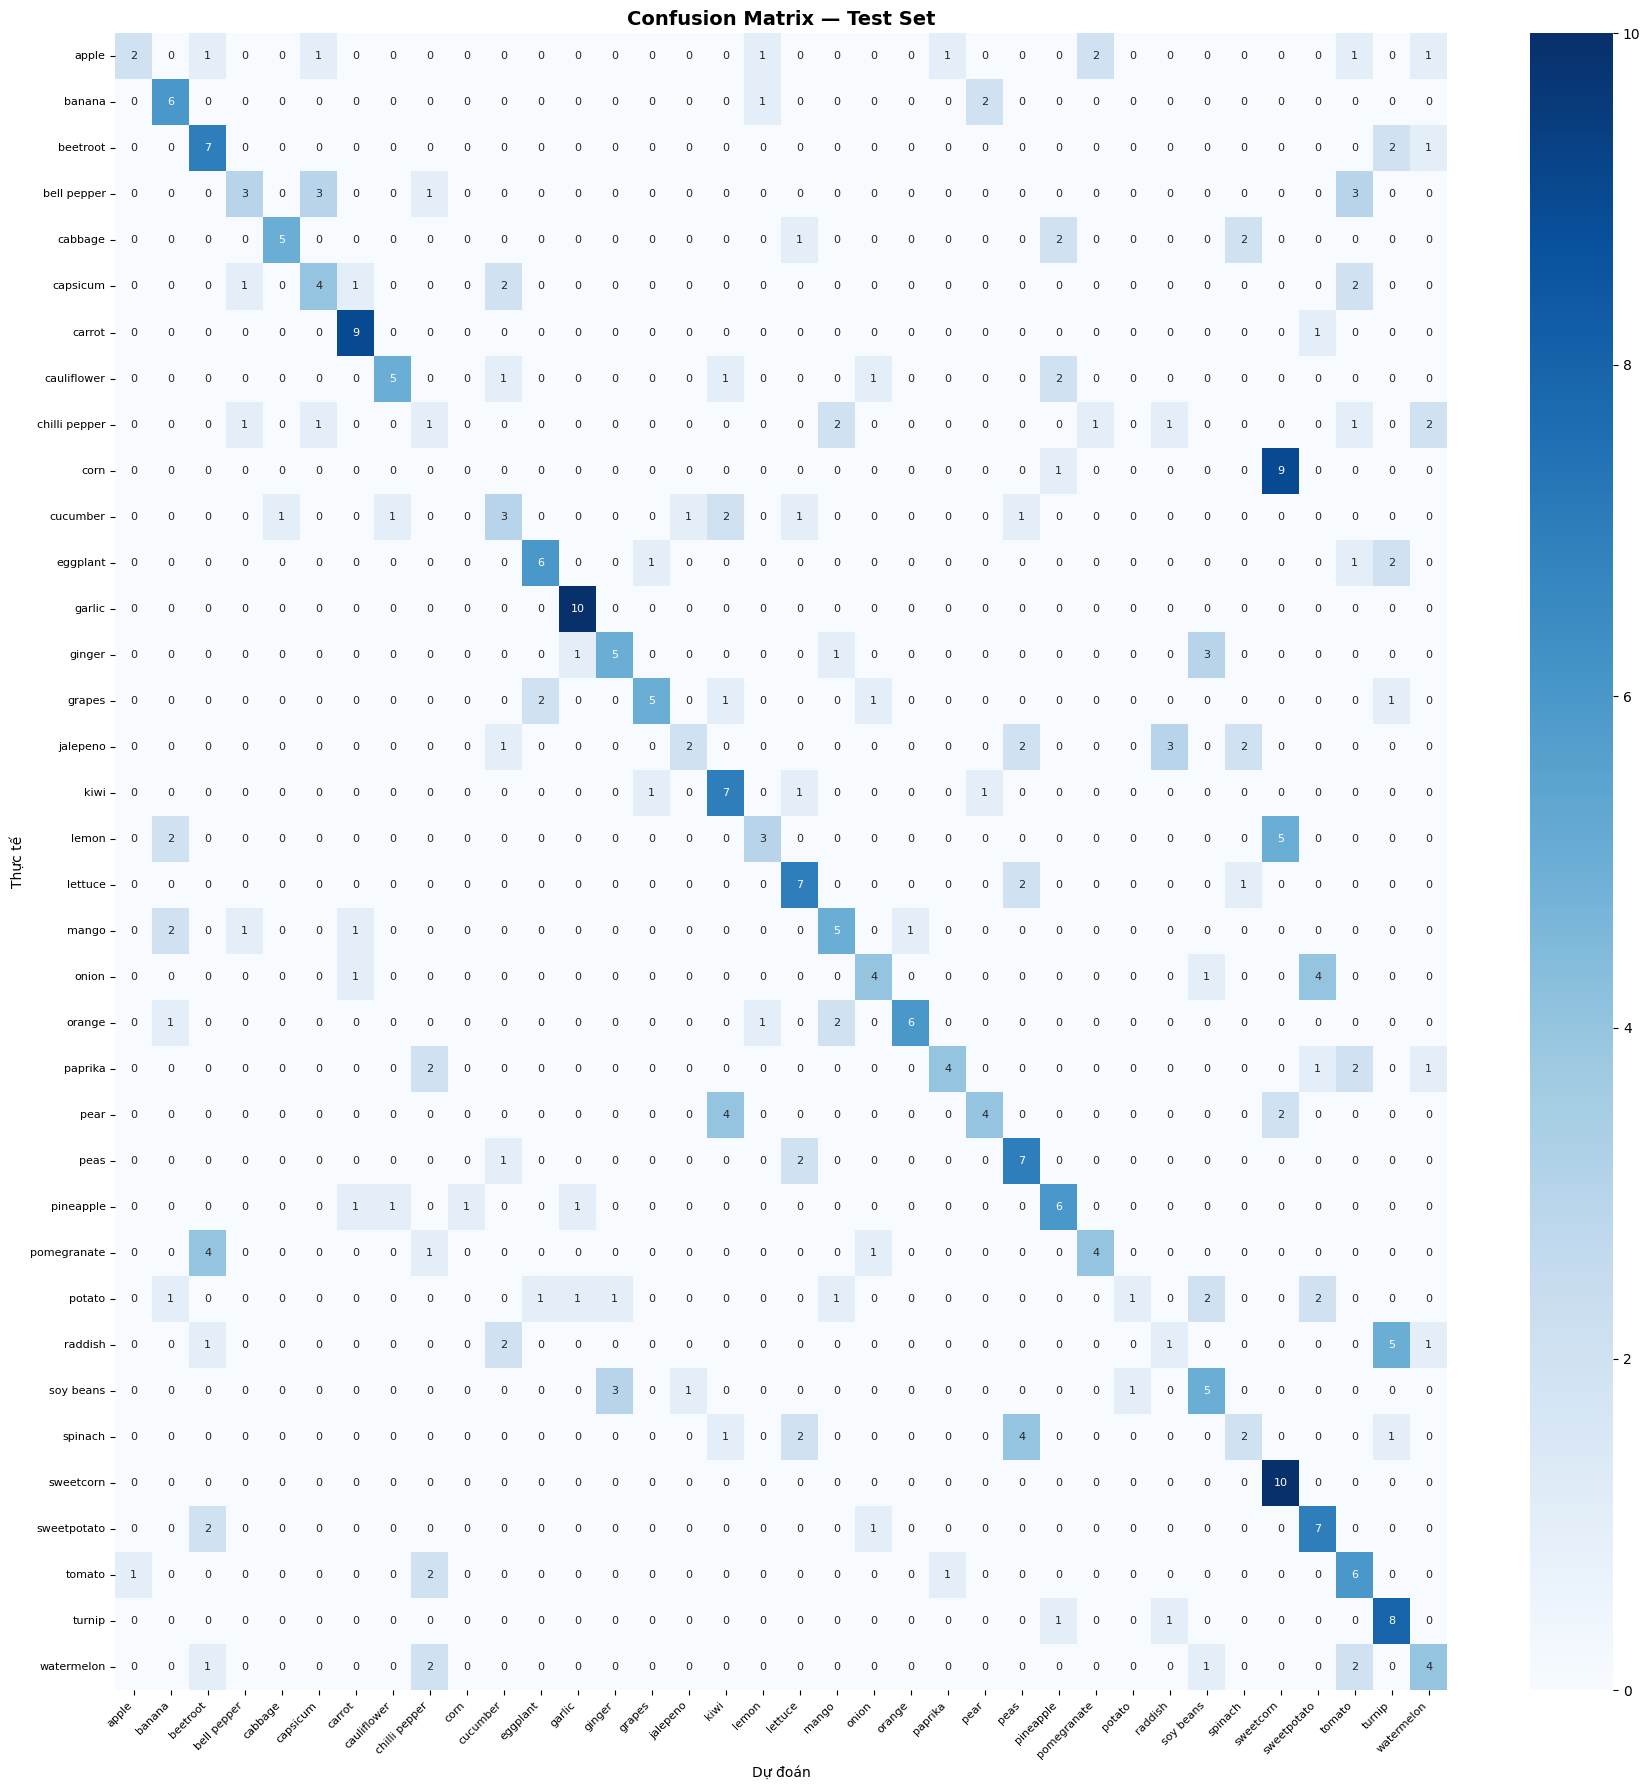


📋 Classification Report:
               precision    recall  f1-score   support

        apple     0.6667    0.2000    0.3077        10
       banana     0.5000    0.6667    0.5714         9
     beetroot     0.4375    0.7000    0.5385        10
  bell pepper     0.5000    0.3000    0.3750        10
      cabbage     0.8333    0.5000    0.6250        10
     capsicum     0.4444    0.4000    0.4211        10
       carrot     0.6923    0.9000    0.7826        10
  cauliflower     0.7143    0.5000    0.5882        10
chilli pepper     0.1111    0.1000    0.1053        10
         corn     0.0000    0.0000    0.0000        10
     cucumber     0.3000    0.3000    0.3000        10
     eggplant     0.6667    0.6000    0.6316        10
       garlic     0.7692    1.0000    0.8696        10
       ginger     0.5556    0.5000    0.5263        10
       grapes     0.7143    0.5000    0.5882        10
     jalepeno     0.5000    0.2000    0.2857        10
         kiwi     0.4375    0.7000    

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
n  = len(class_names)

plt.figure(figsize=(max(10, n//2), max(8, n//2)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 8})
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán'); plt.ylabel('Thực tế')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Classification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Dự đoán ảnh mới

In [ ]:
from PIL import Image
from google.colab import files

print(' Upload ảnh bạn muốn dự đoán:')
uploaded = files.upload()

for img_path in uploaded.keys():
    img = Image.open(img_path).convert('RGB')
    tensor = val_test_transforms(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
        top5_p, top5_i = probs.topk(5)

    #  Chuyển sang list trước khi reverse
    top5_p_list = top5_p.cpu().tolist()
    top5_i_list = top5_i.cpu().tolist()
    labels_top5 = [class_names[i] for i in top5_i_list]

    # Hiển thị ảnh
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(img); plt.axis('off')
    plt.title(f'Ảnh: {img_path}', fontsize=10)

    plt.subplot(1, 2, 2)
    colors = ['#2ecc71'] + ['#95a5a6'] * 4
    bars = plt.barh(labels_top5[::-1], [p*100 for p in top5_p_list[::-1]], color=colors[::-1])
    plt.xlabel('Xác suất (%)')
    plt.title('Top-5 dự đoán', fontsize=11, fontweight='bold')
    for bar, p in zip(bars, top5_p_list[::-1]):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{p*100:.1f}%', va='center', fontsize=9)
    plt.xlim(0, 115)
    plt.tight_layout()
    plt.show()

    print(f'👉 Kết quả: {class_names[top5_i_list[0]]} ({top5_p_list[0]*100:.2f}%)')

 Upload ảnh bạn muốn dự đoán:


Tải kết quả về máy

In [13]:
from google.colab import files

files.download('best_model.pth')
files.download('training_history.png')
files.download('confusion_matrix.png')
print(' Đã tải xong!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Đã tải xong!
